# BIC Optimization for Hyperbolic Embedding

This notebook finds the optimal embedding dimension for a given distance matrix by minimizing the Bayesian Information Criterion (BIC). It iterates through a range of possible dimensions, performs the HMDS embedding for each, and plots the BIC to find the 'elbow' point, which represents the best trade-off between model complexity and goodness of fit.

### 1. Import Libraries

Import necessary libraries and functions. `run_embedding` and `load_dmat_from_mat` are imported from our helper script. We also import `matplotlib` for plotting and `pickle` for caching results.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from analysis_from_mat import load_dmat_from_mat, run_embedding

print("Modules imported successfully!")

Modules imported successfully!


### 2. Set Analysis Parameters

Define file paths, variable names, and the range of dimensions to test. If you have an uncertainty matrix, provide its variable name; otherwise, set it to `None`.

In [ ]:
# --- Data and Caching Parameters ---
mat_file_path = 'data/distance_matrix_fish1.mat'      # <-- UPDATE THIS PATH
matrix_variable_name = 'distanceMatrix_laserOn' # <-- UPDATE THIS VARIABLE NAME
uncertainty_variable_name = 'var_dij_laserOn' # <-- UPDATE THIS, or set to None if not applicable

# --- Optimization Parameters ---
# Define the range of embedding dimensions to test.
dim_range = range(2, 10) # e.g., test dimensions from 3 to 9

# --- Caching Parameters ---
force_rerun = False
results_path = 'results/bic_results_laserOn.pkl'

# --- Plotting Parameters ---
plot_output_path = 'Figure/bic_vs_dimension_laserOn.pdf' # Set to None to disable saving

### 3. Load Data

Load the distance matrix and the uncertainty matrix (if specified).

In [ ]:
print(f"Loading distance matrix '{matrix_variable_name}' from: {mat_file_path}")
distance_matrix = load_dmat_from_mat(mat_file_path, matrix_variable_name)

uncertainty_matrix = None
if uncertainty_variable_name:
    print(f"Loading uncertainty matrix '{uncertainty_variable_name}' from: {mat_file_path}")
    uncertainty_matrix = load_dmat_from_mat(mat_file_path, uncertainty_variable_name)

Loading distance matrix 'distanceMatrix_laserOn' from: data/distance_matrix_fish1.mat
Successfully loaded matrix 'distanceMatrix_laserOn' with shape: (611, 611)
Loading uncertainty matrix 'var_dij_laserOn' from: data/distance_matrix_fish1.mat
Successfully loaded matrix 'var_dij_laserOn' with shape: (611, 611)


### 4. Run Embedding Loop to Find Optimal Dimension

This cell iterates through each dimension in `dim_range`, runs the embedding, and stores the BIC. It uses caching to avoid re-running the analysis if results are already saved.

In [7]:
bic_results = {}

if os.path.exists(results_path) and not force_rerun:
    print(f"Loading cached results from {results_path}")
    with open(results_path, 'rb') as f:
        bic_results = pickle.load(f)
else:
    print("Running embedding for all dimensions... This may take a long time.")
    for dim in dim_range:
        print(f"\n--- Testing Dimension: {dim} ---")
        fit = run_embedding(dmat=distance_matrix, 
                            embedding_dim=dim, 
                            dmat_unc=uncertainty_matrix,
                            verbose=False) # Set verbose=True for more output
        bic_results[dim] = fit['bic']
        print(f"--> Dimension: {dim}, BIC: {fit['bic']:.2f}")
    
    # Cache the results
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    with open(results_path, 'wb') as f:
        pickle.dump(bic_results, f)
    print(f"\nBIC results saved to {results_path}")

# Find the optimal dimension
if bic_results:
    optimal_dim = min(bic_results, key=bic_results.get)
    min_bic = bic_results[optimal_dim]
    print(f"\nOptimal Embedding Dimension: {optimal_dim} (BIC: {min_bic:.2f})")
else:
    print("\nNo results to analyze.")

Loading cached results from results/bic_results_laserOn.pkl

Optimal Embedding Dimension: 6 (BIC: -228094.37)


### 5. Plot BIC vs. Embedding Dimension

Visualize the BIC scores to identify the 'elbow point' where the BIC value stabilizes or begins to increase.

Saving BIC plot to results/bic_vs_dimension_laserOn.pdf...


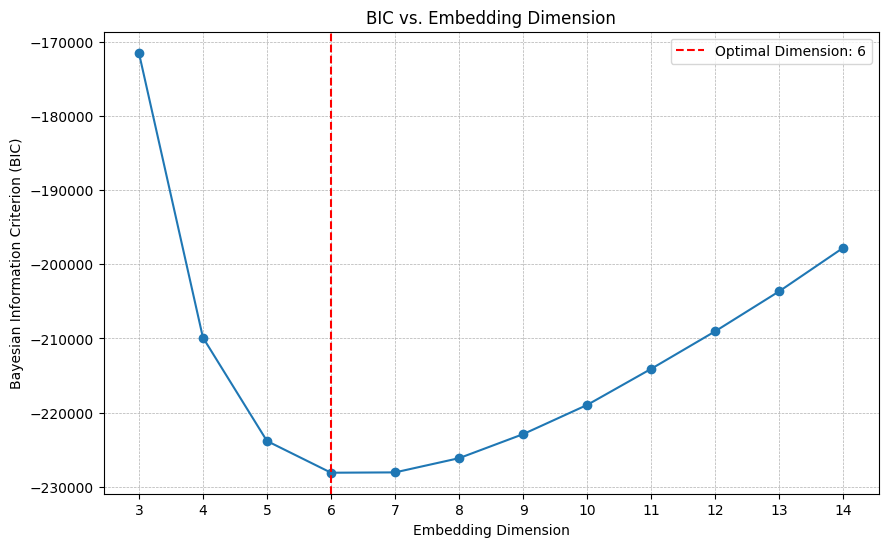

In [8]:
if bic_results:
    dims = sorted(bic_results.keys())
    bics = [bic_results[d] for d in dims]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(dims, bics, marker='o', linestyle='-')
    ax.axvline(x=optimal_dim, color='r', linestyle='--', label=f'Optimal Dimension: {optimal_dim}')

    ax.set_title('BIC vs. Embedding Dimension')
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('Bayesian Information Criterion (BIC)')
    ax.set_xticks(dims)
    ax.legend()
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Save the plot if a path is provided
    if plot_output_path:
        print(f"Saving BIC plot to {plot_output_path}...")
        fig.savefig(plot_output_path, format='pdf', bbox_inches='tight')

    plt.show()
else:
    print("No data to plot.")